# Notebook 01 --- Exploratory Data Analysis

**Speech Emotion Recognition (SER) on the RAVDESS Dataset**

This Notebook shows the exploriterly phase of the project and checking the paths and data are collected correctly

1. Parse the RAVDESS filenames into a structured metadata table
2. Verify dataset coverage (file counts, actors, channels)
3. Examine class distributions (emotion, channel, gender, intensity)
4. Analyze audio properties (duration distribution)
5. Visualize representative waveforms and Mel spectrograms

**Output:** `features/metadata.csv`, consumed by every subsequent notebook.



## Setup and imports

In [1]:
import sys
from pathlib import Path

# This been used to add the project as a parent project, so we can import our packages

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from ser.data import build_metadata

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project


## 1. Build the metadata table

The RAVDESS filenames encode every ground-truth label (emotion, intensity, statement,
repetition, actor). We walk the `data/` directory recursively and parse each filename.

**Folder layout in this project:**
***
data/
├── audio_speech_actors/Actor_01/.wav
├── audio_speech_actors/Actor_02/.wav
│   ...
├── audio_song_actors/Actor_01/.wav
└── audio_song_actors/Actor_02/.wav
***
`build_metadata` uses `Path.rglob("*.wav")`, which is **recursive** — it finds every
WAV file regardless of subfolder depth, so the speech/song split into two parent
folders is handled transparently. The speech-vs-song label comes from **position 2
of the filename** (`01` = speech, `02` = song), not the folder name.

In [2]:
DATA_ROOT = PROJECT_ROOT / "data"
assert DATA_ROOT.exists(), f"Data root not found: {DATA_ROOT}"

expected_subdirs = ["audio_speech_actors", "audio_song_actors"]
for sub in expected_subdirs:
    p = DATA_ROOT / sub
    print(f"  {sub:<25} exists={p.exists()}")

meta = build_metadata(DATA_ROOT)
print(f"\nTotal files parsed: {len(meta)}")
meta.head()

  audio_speech_actors       exists=True
  audio_song_actors         exists=True

Total files parsed: 2452


,filename,modality,channel,emotion,emotion_code,intensity,statement,repetition,actor,gender,path
0,03-02-01-01-01-01-01.wav,audio-only,song,neutral,1,normal,Kids are talking by the door,1,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
1,03-02-01-01-01-02-01.wav,audio-only,song,neutral,1,normal,Kids are talking by the door,2,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
2,03-02-01-01-02-01-01.wav,audio-only,song,neutral,1,normal,Dogs are sitting by the door,1,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
3,03-02-01-01-02-02-01.wav,audio-only,song,neutral,1,normal,Dogs are sitting by the door,2,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...
4,03-02-02-01-01-01-01.wav,audio-only,song,calm,2,normal,Kids are talking by the door,1,1,male,C:\Users\rbk55\OneDrive\Documents\Project_CSE4...


### Sanity checks

Expected counts (from RAVDESS documentation):

- **Speech:** 60 files × 24 actors = **1,440**
- **Song:** 44 files × 23 actors (actor 18 has no song) = **1,012**
- **Total:** **2,452**

In [3]:
print("Files by channel:")
print(meta["channel"].value_counts(), "\n")

print("Unique actors per channel (speech=24, song=23):")
print(meta.groupby("channel")["actor"].nunique(), "\n")

song_actors = set(meta[meta["channel"] == "song"]["actor"].unique())
missing = sorted(set(range(1, 25)) - song_actors)
print(f"Actor(s) missing from song subset: {missing}")

Files by channel:
channel
speech    1440
song      1012
Name: count, dtype: int64 

Unique actors per channel (speech=24, song=23):
channel
song      23
speech    24
Name: actor, dtype: int64 

Actor(s) missing from song subset: [18]


### Persist metadata for downstream notebooks


In [4]:
META_PATH = PROJECT_ROOT / "features" / "metadata.csv"
META_PATH.parent.mkdir(parents=True, exist_ok=True)
meta.to_csv(META_PATH, index=False)
print(f"Saved {len(meta)} rows to {META_PATH}")

Saved 2452 rows to c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project\features\metadata.csv


## 2. Class distribution analysis

The classification target is the "emotion", and we have 8 classes given the dataset. Knowing the imlance of classes is important, because it is obviously will affect
the way that we will evaluate the data. For example heavey implanced data favor F1-macro because every class weighted equally


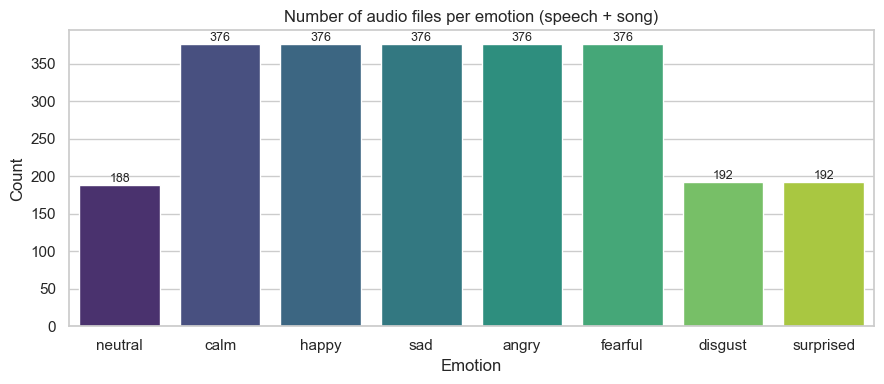

In [5]:
order = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=meta, x="emotion", order=order, hue="emotion",
              palette="viridis", legend=False, ax=ax)
ax.set_title("Number of audio files per emotion (speech + song)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "class_distribution.png", dpi=120)
plt.show()

**Observation.** Most emotions have similar counts; `neutral` has roughly half because
RAVDESS does not include a *strong*-intensity version of neutral speech as I understand from there descreptions of their dataset.

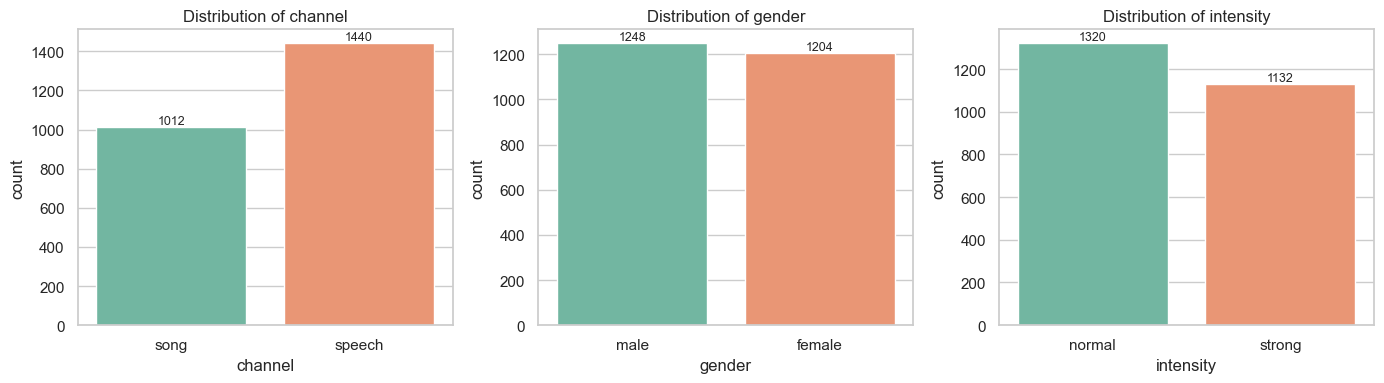

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["channel", "gender", "intensity"]):
    sns.countplot(data=meta, x=col, hue=col, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
    for p in ax.patches:
        ax.annotate(int(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "demographic_distribution.png", dpi=120)
plt.show()

**Observation.**
- **Channel:** speech has more files than song (60 vs 44 per actor).
- **Gender:** perfectly balanced --- 12 male and 12 female actors. As I rembember the actor number 18 is missing in a one of folders
- **Intensity:** roughly balanced; `normal` is slightly more frequent because all
  `neutral` files are recorded only at normal intensity.

### Emotion coverage in speech vs song
important RAVDESS detail: the **song** subset only contains 6 emotions
(neutral, calm, happy, sad, angry, fearful). `disgust` and `surprised` are speech-only.

channel    song  speech
emotion                
neutral      92      96
calm        184     192
happy       184     192
sad         184     192
angry       184     192
fearful     184     192
disgust       0     192
surprised     0     192 



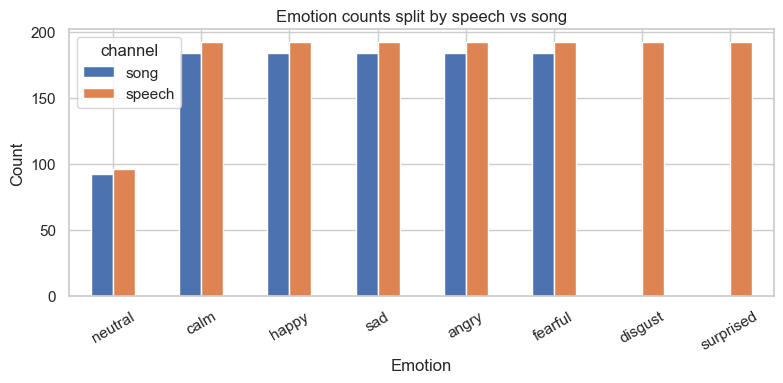

In [7]:
ct = pd.crosstab(meta["emotion"], meta["channel"]).reindex(order)
print(ct, "\n")

fig, ax = plt.subplots(figsize=(8, 4))
ct.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Emotion counts split by speech vs song")
ax.set_ylabel("Count")
ax.set_xlabel("Emotion")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "emotion_by_channel.png", dpi=120)
plt.show()

## 3. Audio property analysis

Each WAV file has a different duration, so we can't give that directly to classifier, the expect fixed-length feature vectors. Here will show some standard stastics like mean and standard deviation, which produces one fixed-length vector per file regardless of original length. Only 200 file been sampled for fast scan.

Reading audio: 100%|██████████| 200/200 [00:00<00:00, 210.87it/s]


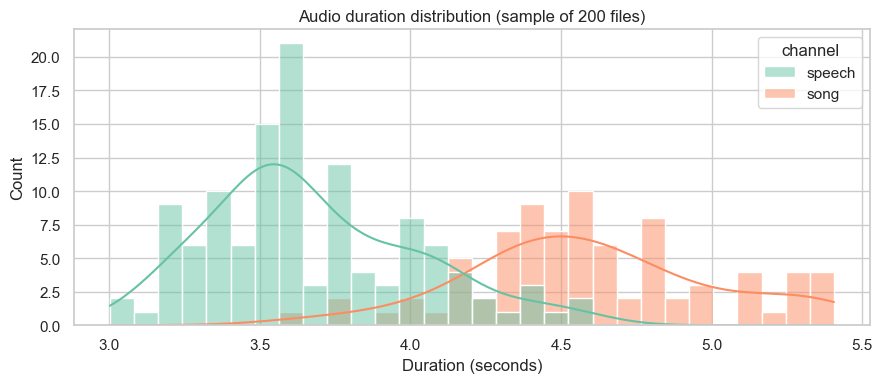

         count      mean       std       min       25%       50%       75%  \
channel                                                                      
song      81.0  4.597596  0.405399  3.603604  4.337667  4.571229  4.804812   
speech   119.0  3.673138  0.341701  3.003000  3.453448  3.603583  3.903906   

              max  
channel            
song     5.405417  
speech   4.604583  


In [8]:
sample = meta.sample(200, random_state=42).reset_index(drop=True)
durations = []
for path in tqdm(sample["path"], desc="Reading audio"):
    durations.append(librosa.get_duration(path=path))
sample["duration"] = durations

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=sample, x="duration", hue="channel", bins=30,
             kde=True, ax=ax, palette="Set2")
ax.set_title("Audio duration distribution (sample of 200 files)")
ax.set_xlabel("Duration (seconds)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "duration_distribution.png", dpi=120)
plt.show()

print(sample.groupby("channel")["duration"].describe())

The figure shows the distribution of audio file durations split by channel. Speech files cluster tightly around 3.5 seconds; song files are longer and more variable, around 4.5 seconds with a wider spread. The variation across files is what motivates the next step: since classifiers need fixed-length input, I extract per-frame features and summarize them with statistics like mean and standard deviation, which produces one fixed-length vector per file regardless of original duration

## 4. Visual contrast: calm vs angry

To motivate the feature extraction step, we visualize a low-arousal emotion (calm)
and a high-arousal emotion (angry) from the same actor. Differences in **amplitude**,
**spectral content**, and **dynamics** are exactly what MFCCs and spectral features
are designed to capture.

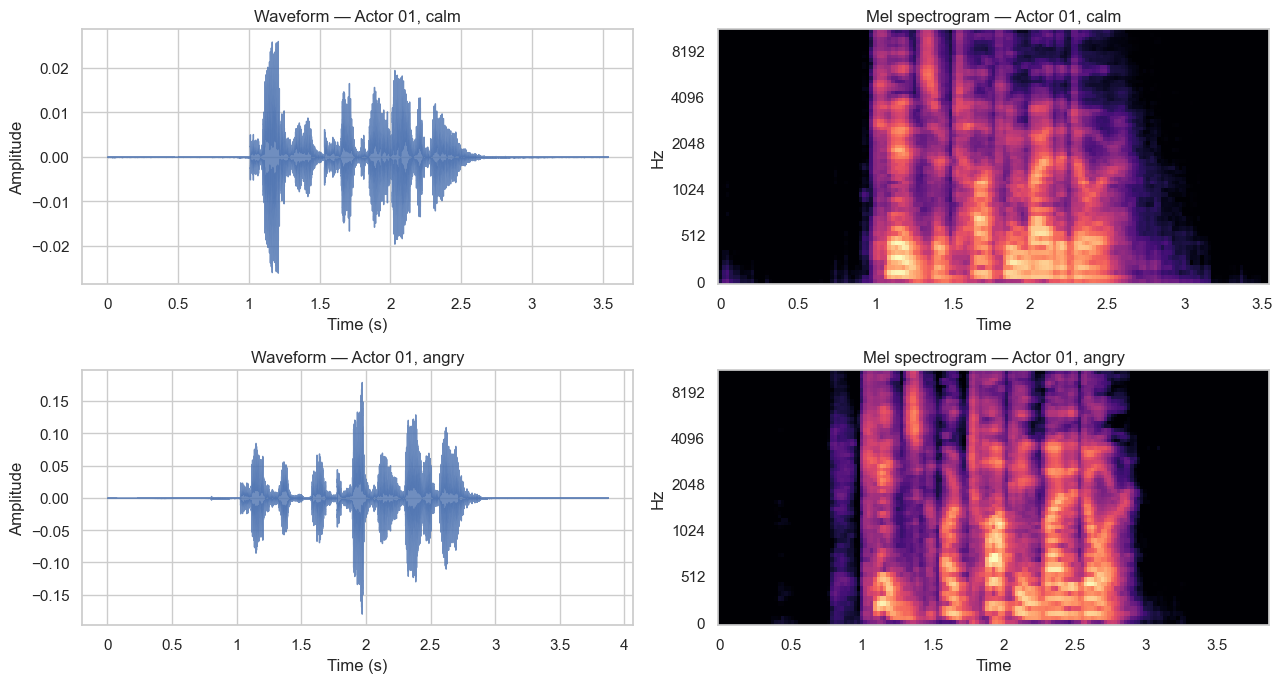

In [9]:
def show_audio(path, title, ax_wave, ax_spec, sr=22050):
    """Plot waveform and Mel spectrogram of a single audio file."""
    y, sr = librosa.load(path, sr=sr)
    librosa.display.waveshow(y, sr=sr, ax=ax_wave, alpha=0.8)
    ax_wave.set_title(f"Waveform — {title}")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis="time",
                             y_axis="mel", ax=ax_spec, cmap="magma")
    ax_spec.set_title(f"Mel spectrogram — {title}")

# Pick one calm and one angry speech file from actor 1
actor1_speech = meta[(meta["actor"] == 1) & (meta["channel"] == "speech")]
calm_path  = actor1_speech[actor1_speech["emotion"] == "calm"].iloc[0]["path"]
angry_path = actor1_speech[actor1_speech["emotion"] == "angry"].iloc[0]["path"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
show_audio(calm_path,  "Actor 01, calm",  axes[0, 0], axes[0, 1])
show_audio(angry_path, "Actor 01, angry", axes[1, 0], axes[1, 1])
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "waveform_spectrogram_examples.png", dpi=120)
plt.show()

**Observation.** The angry clip is much louder than the calm one and has energy spread across higher frequencies, with sharper onsets. These differences in loudness, spectral content, and dynamics are what audio features like RMS, spectral centroid, and MFCCs are designed to capture, motivating the feature set we extract next.

**## EDA Findings - Summary

| Aspect | Finding | Implication |
|---|---|---|
| Total files | 2,452 (1,440 speech + 1,012 song) | Sufficient for classical ML; small for deep learning. |
| Class balance | 7 emotions ~equal, `neutral` ~half | Use **macro-F1**, not raw accuracy, as the primary metric. |
| Channel coverage | Song lacks `disgust` and `surprised` | If combining channels, expect class–channel correlation. |
| Gender | Perfectly balanced (12 M, 12 F) | Speaker- and gender-stratified evaluation is feasible. |
| Duration | Variable, ~3–5 s | Need fixed-length feature vectors → per-frame summary stats. |
| Spectral contrast | Angry vs calm differ markedly in energy and spread | MFCCs + spectral + energy features are well-motivated. |

**Output of this notebook:** `features/metadata.csv` - used by every subsequent notebook.

In [10]:
from ser.feature import extract_features, get_feature_names
import numpy as np

test_path = meta.iloc[0]["path"]
print(f"Testing on: {test_path}\n")

vec = extract_features(test_path)
names = get_feature_names()


vec_float = np.asarray(vec, dtype=float)
print(f"Vector dtype:    {vec.dtype}")
print(f"Vector shape:    {vec.shape}")
print(f"Feature names:   {len(names)}")
print(f"Any NaN values?  {bool(np.isnan(vec_float).any())}")
print(f"First 5 values:  {vec_float[:5]}")
print(f"\nFirst 5 names:   {names[:5]}")
print(f"Last 5 names:    {names[-5:]}")

Testing on: C:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project\data\audio_song_actors\Actor_01\03-02-01-01-01-01-01.wav

Vector dtype:    float64
Vector shape:    (112,)
Feature names:   112
Any NaN values?  False
First 5 values:  [-427.58981323   92.76052856  -31.06323814   20.30632019   -1.92900443]

First 5 names:   ['mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean', 'mfcc4_mean', 'mfcc5_mean']
Last 5 names:    ['centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std']
